In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,  mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import impute
from sklearn import preprocessing
import numpy as np
import warnings
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold, train_test_split


In [ ]:
df = pd.read_csv('/kaggle/input/df-test/resultwithfeatures.csv', low_memory=False)


In [ ]:
df

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pan

,Source,Smiles,Exp. Animal,Method of administration,LD50,LD50 (a.u.),Carcinogenicity,Carcinogenicity (a.u.),Hepatoxicity,Hepatoxicity (a.u.),...,MorganFP_1015,MorganFP_1016,MorganFP_1017,MorganFP_1018,MorganFP_1019,MorganFP_1020,MorganFP_1021,MorganFP_1022,MorganFP_1023,MorganFP_1024
0,ChEMBL,Br.Br.Cc1cc(-c2ccc(O)cc2)nnc1NCCN1CCOCC1,mouse,intraperitoneal,300.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1,ChEMBL,Br.Br.Cc1cc(-c2cccc(O)c2)nnc1NCCN1CCOCC1,mouse,intraperitoneal,200.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2,ChEMBL,Br.Br.Cc1cc(-c2ccccc2O)nnc1NCCN1CCOCC1,mouse,intraperitoneal,200.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
3,ChEMBL,Br.CC(C)C(N)C(=O)NNc1nncc(-c2ccc(Cl)cc2)n1.O,mouse,intraperitoneal,178.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,1,0
4,ChEMBL,Br.CC(C)N(CCCOc1ccc(N/C(=N\c2ccccc2)c2ccccc2)c...,mouse,intraperitoneal,140.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114752,PubChem,CC1C=CC=CC=CC=CC=CC=CC=CC(CC2C(C(C[C@](O2)(CC(...,mouse,intravenous,4.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,1,0,0,0,0
114753,PubChem,CC1C=CC=CC=CC=CC=CC=CC=CC(CC2C(C(C[C@](O2)(CC(...,mouse,intraperitoneal,88.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,1,0,0,0,0
114754,PubChem,C1C(C2C3C1C4[C@@]5([C@@]2(C([C@]3([C@]45Cl)Cl)...,mouse,oral,500.0,mg/kg,NaN,NaN,NaN,NaN,...,0,1,0,0,0,1,0,0,0,0
114755,PubChem,CC1=CC2=C(C=C1C)N(C=N2)C3C(C(C(O3)CO)OP(=O)([O...,mouse,intravenous,2000.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,1,1,0,0,0,0


In [ ]:
df.describe()

/usr/local/lib/python3.10/dist-packages/pandas/core/nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarnin

,LD50,Carcinogenicity,Carcinogenicity (a.u.),Hepatoxicity,Hepatoxicity (a.u.),Eye_Corrosion,Eye_Corrosion (a.u.),Eye_Irritation,Eye_Irritation (a.u.),Mutagenicity,...,MorganFP_1015,MorganFP_1016,MorganFP_1017,MorganFP_1018,MorganFP_1019,MorganFP_1020,MorganFP_1021,MorganFP_1022,MorganFP_1023,MorganFP_1024
count,9.921700e+04,1099.000000,0.0,3346.000000,0.0,2627.000000,0.0,5577.000000,0.0,7836.000000,...,114757.000000,114757.000000,114757.000000,114757.000000,114757.000000,114757.000000,114757.000000,114757.000000,114757.000000,114757.000000
mean,1.627611e+03,0.481347,NaN,0.510460,NaN,0.347164,NaN,0.708087,NaN,0.548111,...,0.025367,0.012731,0.006326,0.094068,0.013489,0.277595,0.023380,0.016522,0.017881,0.008287
std,2.196844e+04,0.499879,NaN,0.499965,NaN,0.476159,NaN,0.454683,NaN,0.497712,...,0.157237,0.112113,0.079287,0.291925,0.115358,0.447815,0.151107,0.127472,0.132520,0.090656
min,0.000000e+00,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000e+02,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000e+02,0.000000,NaN,1.000000,NaN,0.000000,NaN,1.000000,NaN,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000033e+03,1.000000,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2.500000e+06,1.000000,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Первичная предобработка

In [ ]:
df.columns[:25]

Index(['Source', 'Smiles', 'Exp. Animal', 'Method of administration', 'LD50',
       'LD50 (a.u.)', 'Carcinogenicity', 'Carcinogenicity (a.u.)',
       'Hepatoxicity', 'Hepatoxicity (a.u.)', 'Eye_Corrosion',
       'Eye_Corrosion (a.u.)', 'Eye_Irritation', 'Eye_Irritation (a.u.)',
       'Mutagenicity', 'Mutagenicity (a.u.)', 'Respiratory_Toxicity',
       'Respiratory_Toxicity (a.u.)', 'LC50', 'LC50 (a.u.)', 'NOAEL',
       'NOAEL (a.u)', 'MaxAbsEStateIndex', 'MaxEStateIndex',
       'MinAbsEStateIndex'],
      dtype='object')

In [ ]:
df = df.drop_duplicates(subset = ['Smiles', 'Exp. Animal', 'Method of administration'])
df.shape

(114033, 1422)

In [ ]:
df.memory_usage(deep=True).sum() / 1024

1310574.7802734375

In [ ]:
cat_features_mask = (df.dtypes == "object").values

obj_cols = df.select_dtypes('object').columns
df[obj_cols] = df[obj_cols].astype('category')

<ipython-input-16-1b999221a91c>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[obj_cols] = df[obj_cols].astype('category')


In [ ]:
df.memory_usage(deep=True).sum() / 1024

1273943.888671875

In [ ]:
fcols = df.select_dtypes('float').columns
icols = df.select_dtypes('integer').columns

df[fcols] = df[fcols].apply(pd.to_numeric, downcast='float')
df[icols] = df[icols].apply(pd.to_numeric, downcast='integer')

<ipython-input-18-5b58077432c7>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[fcols] = df[fcols].apply(pd.to_numeric, downcast='float')
<ipython-input-18-5b58077432c7>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[icols] = df[icols].apply(pd.to_numeric, downcast='integer')


In [ ]:
df.memory_usage(deep=True).sum() / 1024

249985.4560546875

In [ ]:
df = df.drop_duplicates(subset = ['Smiles', 'Exp. Animal', 'Method of administration'])
df.shape

(114033, 1422)

In [ ]:
df = df.drop(['Source', 'Smiles',
       'LD50 (a.u.)', 'Carcinogenicity', 'Carcinogenicity (a.u.)',
       'Hepatoxicity', 'Hepatoxicity (a.u.)', 'Eye_Corrosion',
       'Eye_Corrosion (a.u.)', 'Eye_Irritation', 'Eye_Irritation (a.u.)',
       'Mutagenicity', 'Mutagenicity (a.u.)', 'Respiratory_Toxicity',
       'Respiratory_Toxicity (a.u.)', 'LC50', 'LC50 (a.u.)', 'NOAEL',
       'NOAEL (a.u)'], axis = 1).reset_index(drop = True)
df.shape

(114033, 1403)

In [ ]:
df.columns
df.shape

(114033, 1403)

In [ ]:
df = df.dropna(subset=['LD50'])
df.shape

(98512, 1403)

In [ ]:
threshold = 0.996

def drop_constant_columns(df, threshold):
    to_drop = []  # Список столбцов для удаления
    for col in df.columns:
        max_freq = df[col].value_counts(normalize=True).max()
        if max_freq >= threshold:
            to_drop.append(col)
    # Удаляем столбцы
    return df.drop(columns=to_drop)

# Применяем функцию
df_cleaned = drop_constant_columns(df, threshold)

In [ ]:
df_cleaned.shape

(98512, 1383)

In [ ]:
df = df_cleaned

In [ ]:
df = df[df['LD50'] > 0].copy()

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df['lof_outlier'] = lof.fit_predict(df[['LD50']])

df = df[df['lof_outlier'] == 1]
df.drop(columns=['lof_outlier'], inplace=True)
df.shape


(93581, 1383)

In [ ]:
df = df.dropna()
df.shape

(90141, 1383)

In [ ]:
df['log_LD50'] = np.log(df['LD50'])

<Axes: >

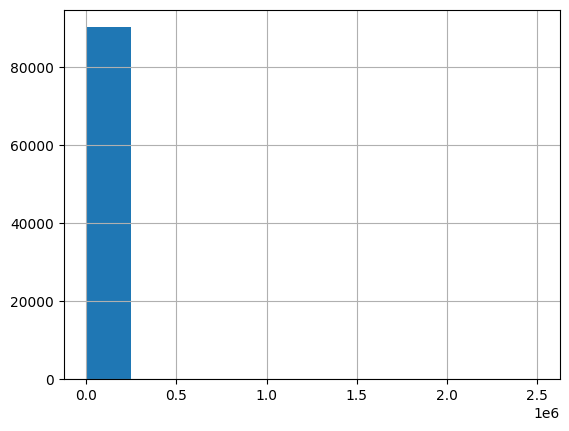

In [ ]:
df['LD50'].hist()

<Axes: >

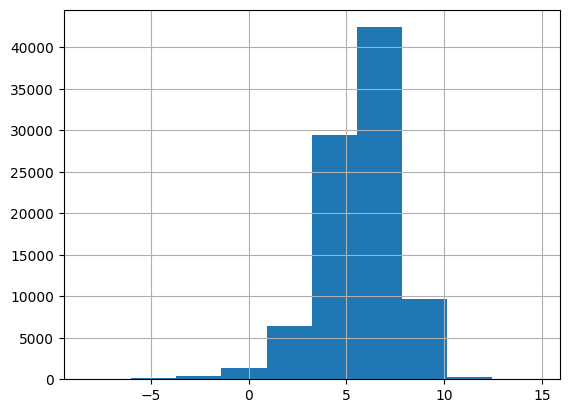

In [ ]:
df['log_LD50'].hist()

In [ ]:
X = df.drop(columns=['LD50', 'log_LD50'])
y = df['log_LD50']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=123)

In [ ]:
num_col = X.select_dtypes(include=['number']).columns.tolist()
cat_col = X.select_dtypes(include=['category']).columns.tolist()

X_train_cat = X_train[cat_col]
X_train_num = X_train[num_col]

X_test_cat = X_test[cat_col]
X_test_num = X_test[num_col]

In [ ]:
OHE = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop = 'first')  # handle_unknown='ignore' для новых категорий в тесте

X_train_encoded = OHE.fit_transform(X_train_cat)
X_test_encoded = OHE.transform(X_test_cat)

ohe_columns = OHE.get_feature_names_out(cat_col)
X_train_cat = pd.DataFrame(X_train_encoded, columns=ohe_columns, index=X_train.index)
X_test_cat = pd.DataFrame(X_test_encoded, columns=ohe_columns, index=X_test.index)

In [ ]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col])
X_test_scaled = scaler.transform(X_test[num_col])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col, index=X_test.index)

In [ ]:
X_train = pd.concat([X_train_cat, X_train_scaled], axis=1)
X_test = pd.concat([X_test_cat, X_test_scaled], axis=1)

In [ ]:
X_train.shape

(67605, 1392)

In [ ]:
import pandas as pd
import numpy as np

# Создаём DataFrame из признаков
df_train = pd.DataFrame(X_train, columns=[f'feature_{i}' for i in range(X_train.shape[1])])

# Вычисляем корреляцию
corr_matrix = df_train.corr().abs()

# Находим признаки с высокой корреляцией
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

# Удаляем сильно коррелированные признаки
X_train_selected = df_train.drop(columns=to_drop).values
X_test_selected = pd.DataFrame(X_test, columns=df_train.columns).drop(columns=to_drop, errors='ignore').values

print(f"Оставлено {X_train_selected.shape[1]} признаков после корреляционного анализа")

Оставлено 1392 признаков после корреляционного анализа


Не помогло

# **Отбор признаков и качество на моделях**

Определяем функцию для расчета метрик на тесте и по кросс-валидации для разных моделей

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import mean_absolute_percentage_error, r2_score, make_scorer
import numpy as np
import pandas as pd

def model(regressor, X_train, X_test, y_train, y_test):

    regressor.fit(X_train, y_train)

    y_pred = regressor.predict(X_test)

    y_pred_exp = np.exp(y_pred)
    y_test_exp = np.exp(y_test)

    # MAPE на тестовых данных
    mape_test = mean_absolute_percentage_error(y_test_exp, y_pred_exp)
    r2_test = r2_score(y_test_exp, y_pred_exp)
    print(f'MAPE на тестовых данных: {mape_test:.4f}, R²: {r2_test:.4f}')

    # Кросс-валидация по MAPE
    mape_scorer = make_scorer(mean_absolute_percentage_error, greater_is_better=False)

    # Прогнозы для кросс-валидации
    y_pred_cv = cross_val_predict(regressor, X_train, y_train, cv=5)


    y_pred_cv_exp = np.exp(y_pred_cv)
    y_train_exp = np.exp(y_train)

    # Рассчитываем MAPE для кросс-валидации
    mape_cv = mean_absolute_percentage_error(y_train_exp, y_pred_cv_exp)
    print(f'Кросс-валидация MAPE: {mape_cv:.4f}')

    # Кросс-валидация по R²
    cv_r2 = cross_val_score(regressor, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    print(f'Кросс-валидация R² - Среднее: {cv_r2.mean():.4f}, Std: {cv_r2.std():.4f}')

    # Важность признаков
    if hasattr(regressor, 'feature_importances_'):
        feature_importances = pd.DataFrame({
            'Feature': X_train.columns,
            'Importance': regressor.feature_importances_
        }).sort_values(by='Importance', ascending=False)
        print("Топ-10 признаков по важности:")
        print(feature_importances.head(10))


# **`ANOVA F-test для регрессии`**

отбор 200 признаков

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(f_regression, k=200)  # k - количество признаков для выбора

#  отбор признаков
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# важность признаков
selected_features = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': selector.scores_
})

# по убыванию важности
selected_features = selected_features.sort_values(by='Score', ascending=False)
print(selected_features.head())


                                  Feature         Score
6    Method of administration_intravenous  13898.209414
7           Method of administration_oral  13017.254667
120                     NumAliphaticRings   2264.639493
0                         Exp. Animal_rat   2159.096923
17                                    SPS   1924.753711


In [ ]:
selected_feature_names = X_train.columns[selector.get_support()]
X_train_selected = X_train[selected_feature_names]
X_test_selected = X_test[selected_feature_names]

In [ ]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, force_row_wise=True)
model(lgbm_model, X_train_selected, X_test_selected, y_train, y_test)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Total Bins 12285
[LightGBM] [Info] Number of data points in the train set: 67605, number of used features: 200
[LightGBM] [Info] Start training from score 5.683317
MAPE на тестовых данных: 11.3115, R²: 0.0371
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Total Bins 12250
[LightGBM] [Info] Number of data points in the train set: 54084, number of used features: 200
[LightGBM] [Info] Start training from score 5.680825
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Total Bins 12253
[LightGBM] [Info] Number of data points in the train set: 54084, number of used features: 200
[LightGBM] [Info] Start training from score 5.680125
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Total Bins 12258
[LightGBM] [Info] Number of data points in the train s

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model(xgb_model, X_train_selected, X_test_selected, y_train, y_test)

MAPE на тестовых данных: 9.0182, R²: 0.1661
Кросс-валидация MAPE: 15.9352
Кросс-валидация R² - Среднее: 0.5936, Std: 0.0084
Топ-10 признаков по важности:
                                      Feature  Importance
2        Method of administration_intravenous    0.112352
56                          NumAliphaticRings    0.038778
1    Method of administration_intraperitoneal    0.031038
140                                       O>1    0.024817
68                                     fr_COO    0.024773
3               Method of administration_oral    0.022631
138                                       C=O    0.019445
78                                   fr_quatN    0.017259
143                                         O    0.016343
106                                      QCH3    0.014732


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.1 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor

catboost_model = CatBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbose=0)
model(catboost_model, X_train_selected, X_test_selected, y_train, y_test)

MAPE на тестовых данных: 36.9049, R²: 0.0173
Кросс-валидация MAPE: 28.0950
Кросс-валидация R² - Среднее: 0.5041, Std: 0.0058
Топ-10 признаков по важности:
                                      Feature  Importance
2        Method of administration_intravenous   23.823631
3               Method of administration_oral    7.097882
1    Method of administration_intraperitoneal    7.091704
14                              BCUT2D_LOGPHI    6.032982
16                               BCUT2D_MRLOW    3.426573
28                                  PEOE_VSA1    3.279914
9                            MaxPartialCharge    2.607607
141                                         N    1.874946
11                                BCUT2D_MWHI    1.458327
12                               BCUT2D_CHGHI    1.428832


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)

model(rf, X_train_selected, X_test_selected, y_train, y_test)

KeyboardInterrupt: 

отбор 100 признаков

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(f_regression, k=100)  # k - количество признаков для выбора

#  отбор признаков
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# важность признаков
selected_features = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': selector.scores_
})

# по убыванию важности
selected_features = selected_features.sort_values(by='Score', ascending=False)
print(selected_features.head())

                                  Feature         Score
6    Method of administration_intravenous  13898.209414
7           Method of administration_oral  13017.254667
120                     NumAliphaticRings   2264.639493
0                         Exp. Animal_rat   2159.096923
17                                    SPS   1924.753711


In [ ]:
selected_feature_names = X_train.columns[selector.get_support()]
X_train_selected = X_train[selected_feature_names]
X_test_selected = X_test[selected_feature_names]

In [ ]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, force_row_wise=True)
model(lgbm_model, X_train_selected, X_test_selected, y_train, y_test)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Total Bins 7298
[LightGBM] [Info] Number of data points in the train set: 67605, number of used features: 100
[LightGBM] [Info] Start training from score 5.683317
MAPE на тестовых данных: 13.9051, R²: 0.0339
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Total Bins 7286
[LightGBM] [Info] Number of data points in the train set: 54084, number of used features: 100
[LightGBM] [Info] Start training from score 5.680825
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Total Bins 7286
[LightGBM] [Info] Number of data points in the train set: 54084, number of used features: 100
[LightGBM] [Info] Start training from score 5.680125
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Total Bins 7284
[LightGBM] [Info] Number of data points in the train set: 

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model(xgb_model, X_train_selected, X_test_selected, y_train, y_test)

MAPE на тестовых данных: 13.4837, R²: 0.1180
Кросс-валидация MAPE: 15.9966
Кросс-валидация R² - Среднее: 0.5733, Std: 0.0082
Топ-10 признаков по важности:
                                     Feature  Importance
2       Method of administration_intravenous    0.210466
34                         NumAliphaticRings    0.051148
1   Method of administration_intraperitoneal    0.044565
48                                  fr_quatN    0.042713
41                                    fr_COO    0.033915
3              Method of administration_oral    0.029178
83                                       C=O    0.023530
84                                       O>1    0.022632
33                  NumAliphaticHeterocycles    0.018748
46                                 fr_lactam    0.018654


In [ ]:
from catboost import CatBoostRegressor

catboost_model = CatBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbose=0)
model(catboost_model, X_train_selected, X_test_selected, y_train, y_test)

MAPE на тестовых данных: 32.7923, R²: 0.0335
Кросс-валидация MAPE: 25.5184
Кросс-валидация R² - Среднее: 0.4798, Std: 0.0077
Топ-10 признаков по важности:
                                     Feature  Importance
2       Method of administration_intravenous   25.967267
3              Method of administration_oral    7.490523
1   Method of administration_intraperitoneal    7.449117
10                             BCUT2D_LOGPHI    6.544095
8                               BCUT2D_CHGHI    2.751445
31                              FractionCSP3    2.434989
33                  NumAliphaticHeterocycles    2.351961
15                                     Chi3n    1.962180
26                                SlogP_VSA2    1.823060
48                                  fr_quatN    1.472472


# **PCA**

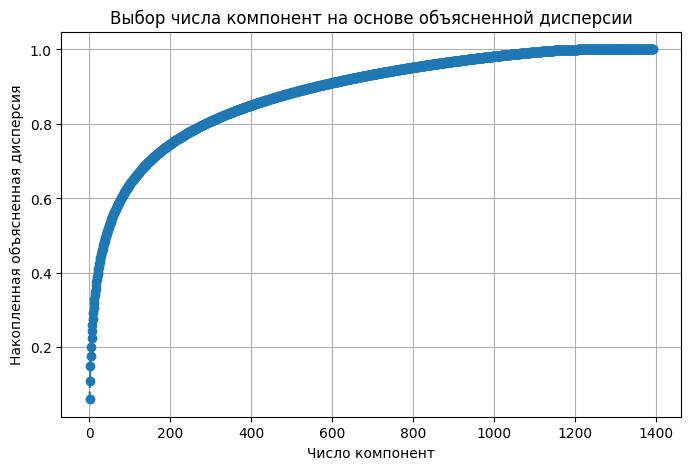

Число компонент для 95% дисперсии: 792


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(X_train)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance.cumsum(), marker='o', linestyle='--')
plt.xlabel('Число компонент')
plt.ylabel('Накопленная объясненная дисперсия')
plt.title('Выбор числа компонент на основе объясненной дисперсии')
plt.grid()
plt.show()

# Выбор компоненты для сохранения 95% дисперсии
cumulative_variance = explained_variance.cumsum()
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Число компонент для 95% дисперсии: {n_components}")


In [ ]:
pca = PCA(n_components=792)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model(xgb_model, X_train_pca, X_test_pca, y_train, y_test)

MAPE на тестовых данных: 10.7085, R²: 0.0157
Кросс-валидация MAPE: 14.1016
Кросс-валидация R² - Среднее: 0.5238, Std: 0.0081


AttributeError: 'numpy.ndarray' object has no attribute 'columns'

Явно одного PCA не хватает + много компонент и обучение долгое

Можно попробовать PCA после применения F-test по отбору 200 признаков

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(f_regression, k=200)  # k - количество признаков для выбора

#  отбор признаков
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# важность признаков
selected_features = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': selector.scores_
})

# по убыванию важности
selected_features = selected_features.sort_values(by='Score', ascending=False)
print(selected_features.head())


                                  Feature         Score
6    Method of administration_intravenous  13898.209414
7           Method of administration_oral  13017.254667
120                     NumAliphaticRings   2264.639493
0                         Exp. Animal_rat   2159.096923
17                                    SPS   1924.753711


In [ ]:
selected_feature_names = X_train.columns[selector.get_support()]
X_train_selected = X_train[selected_feature_names]
X_test_selected = X_test[selected_feature_names]

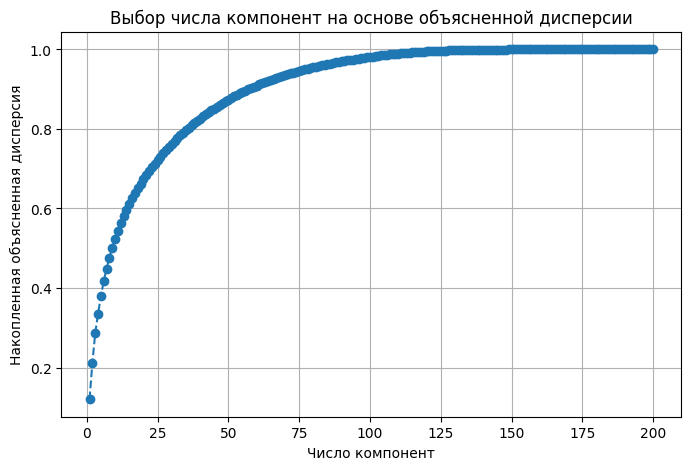

Число компонент для 95% дисперсии: 78


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(X_train_selected)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance.cumsum(), marker='o', linestyle='--')
plt.xlabel('Число компонент')
plt.ylabel('Накопленная объясненная дисперсия')
plt.title('Выбор числа компонент на основе объясненной дисперсии')
plt.grid()
plt.show()

# Выбор компоненты для сохранения 95% дисперсии
cumulative_variance = explained_variance.cumsum()
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Число компонент для 95% дисперсии: {n_components}")


In [ ]:
pca = PCA(n_components=78)
X_train_pca_1 = pca.fit_transform(X_train_selected)
X_test_pca_1 = pca.transform(X_test_selected)

In [ ]:

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model(xgb_model, X_train_pca_1, X_test_pca_1, y_train, y_test)

MAPE на тестовых данных: 13.9687, R²: 0.0044
Кросс-валидация MAPE: 13.0856
Кросс-валидация R² - Среднее: 0.5120, Std: 0.0098


AttributeError: 'numpy.ndarray' object has no attribute 'columns'

# Рекурсивное удаление признаков

In [ ]:
from sklearn.feature_selection import RFE

model_2 = LGBMRegressor(n_estimators=100, n_jobs=-1)
selector = RFE(model, n_features_to_select=200, step=50)
selector.fit(X_train, y_train)

X_train_1 = selector.transform(X_train)
X_test_1 = selector.transform(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.280713 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 28579
[LightGBM] [Info] Number of data points in the train set: 67605, number of used features: 1387
[LightGBM] [Info] Start training from score 5.683317
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.209884 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 28479
[LightGBM] [Info] Number of data points in the train set: 67605, number of used features: 1337
[LightGBM] [Info] Start training from score 5.683317
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.240872 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] To

In [ ]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model(xgb_model, X_train_1, X_test_1, y_train, y_test)

MAPE на тестовых данных: 18.4247, R²: 0.0924
Кросс-валидация MAPE: 18.4129
Кросс-валидация R² - Среднее: 0.6061, Std: 0.0074


AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [ ]:
lgbm_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, force_row_wise=True)
model(lgbm_model, X_train_1, X_test_1, y_train, y_test)

[LightGBM] [Info] Total Bins 23156
[LightGBM] [Info] Number of data points in the train set: 67605, number of used features: 200
[LightGBM] [Info] Start training from score 5.683317
MAPE на тестовых данных: 14.3243, R²: 0.0355
[LightGBM] [Info] Total Bins 23078
[LightGBM] [Info] Number of data points in the train set: 54084, number of used features: 200
[LightGBM] [Info] Start training from score 5.680825
[LightGBM] [Info] Total Bins 23090
[LightGBM] [Info] Number of data points in the train set: 54084, number of used features: 200
[LightGBM] [Info] Start training from score 5.680125
[LightGBM] [Info] Total Bins 23097
[LightGBM] [Info] Number of data points in the train set: 54084, number of used features: 200
[LightGBM] [Info] Start training from score 5.689560
[LightGBM] [Info] Total Bins 23093
[LightGBM] [Info] Number of data points in the train set: 54084, number of used features: 200
[LightGBM] [Info] Start training from score 5.681894
[LightGBM] [Info] Total Bins 23103
[LightGBM]

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

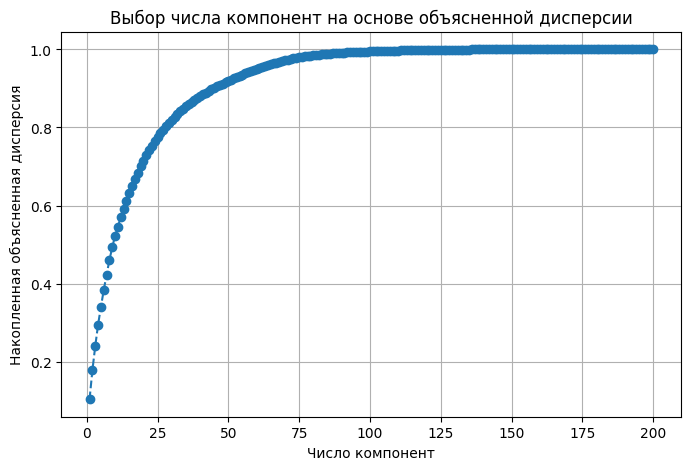

Число компонент для 95% дисперсии: 61


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(X_train_1)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance.cumsum(), marker='o', linestyle='--')
plt.xlabel('Число компонент')
plt.ylabel('Накопленная объясненная дисперсия')
plt.title('Выбор числа компонент на основе объясненной дисперсии')
plt.grid()
plt.show()

# Выбор компоненты для сохранения 95% дисперсии
cumulative_variance = explained_variance.cumsum()
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Число компонент для 95% дисперсии: {n_components}")


In [ ]:
pca = PCA(n_components=61)
X_train_pca = pca.fit_transform(X_train_1)
X_test_pca = pca.transform(X_test_1)

In [ ]:
lgbm_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, force_row_wise=True)
model(lgbm_model, X_train_pca, X_test_pca, y_train, y_test)

[LightGBM] [Info] Total Bins 15555
[LightGBM] [Info] Number of data points in the train set: 67605, number of used features: 61
[LightGBM] [Info] Start training from score 5.683317
MAPE на тестовых данных: 19.1338, R²: 0.0065
[LightGBM] [Info] Total Bins 15555
[LightGBM] [Info] Number of data points in the train set: 54084, number of used features: 61
[LightGBM] [Info] Start training from score 5.680825
[LightGBM] [Info] Total Bins 15555
[LightGBM] [Info] Number of data points in the train set: 54084, number of used features: 61
[LightGBM] [Info] Start training from score 5.680125
[LightGBM] [Info] Total Bins 15555
[LightGBM] [Info] Number of data points in the train set: 54084, number of used features: 61
[LightGBM] [Info] Start training from score 5.689560
[LightGBM] [Info] Total Bins 15555
[LightGBM] [Info] Number of data points in the train set: 54084, number of used features: 61
[LightGBM] [Info] Start training from score 5.681894
[LightGBM] [Info] Total Bins 15555
[LightGBM] [Inf

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [ ]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model(xgb_model, X_train_pca, X_test_pca, y_train, y_test)

MAPE на тестовых данных: 20.3124, R²: 0.0282
Кросс-валидация MAPE: 17.3820
Кросс-валидация R² - Среднее: 0.5327, Std: 0.0061


AttributeError: 'numpy.ndarray' object has no attribute 'columns'

# Boruta

сравнивает "реальные" признаки с искусственными шумовыми (shuffled) и оставляет только те, что существенно важнее шума.

In [ ]:
!pip install boruta

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.2 MB/s eta 0:00:00


In [ ]:
from boruta import BorutaPy
from lightgbm import LGBMRegressor
import pandas as pd

base_model = LGBMRegressor(n_estimators=100, random_state=42)

boruta = BorutaPy(base_model, n_estimators=500, verbose=1, random_state=42)

boruta.fit(X_train.values, y_train.values)

selected_features = X_train.columns[boruta.support_]

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print(f"Отобрано {len(selected_features)} признаков из {X_train.shape[1]}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 5.025993 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 57158
[LightGBM] [Info] Number of data points in the train set: 67605, number of used features: 2774
[LightGBM] [Info] Start training from score 5.683317
Iteration: 1 / 100
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 3.800732 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 57158
[LightGBM] [Info] Number of data points in the train set: 67605, number of used features: 2774
[LightGBM] [Info] Start training from score 5.683317


KeyboardInterrupt: 

# Тюнинг бустинга

In [ ]:
!pip install optuna

In [ ]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 5, 10),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'random_state': 42
    }


    model = XGBRegressor(**param)

    y_pred_cv = cross_val_predict(model, X_train_pca_1, y_train, cv=3)


    y_pred_cv_exp = np.exp(y_pred_cv)
    y_train_exp = np.exp(y_train)
    mape_cv = mean_absolute_percentage_error(y_train_exp, y_pred_cv_exp)

    return mape_cv


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20, n_jobs=-1)


print(f'Лучшие гиперпараметры: {study.best_params}')
print(f'Лучший результат (MAPE): {study.best_value}')


[I 2025-03-12 19:09:09,236] A new study created in memory with name: no-name-ac62b880-ece9-4d04-9cee-aa321ec4f5af
[I 2025-03-12 19:09:14,419] Trial 2 finished with value: 38.573169342691045 and parameters: {'n_estimators': 8, 'max_depth': 7}. Best is trial 2 with value: 38.573169342691045.
[I 2025-03-12 19:09:17,773] Trial 4 finished with value: 69.42721312988162 and parameters: {'n_estimators': 9, 'max_depth': 3}. Best is trial 2 with value: 38.573169342691045.
[I 2025-03-12 19:09:23,680] Trial 3 finished with value: 22.129261862543597 and parameters: {'n_estimators': 5, 'max_depth': 11}. Best is trial 3 with value: 22.129261862543597.
[I 2025-03-12 19:09:39,940] Trial 5 finished with value: 22.464587157880906 and parameters: {'n_estimators': 6, 'max_depth': 12}. Best is trial 3 with value: 22.129261862543597.
[I 2025-03-12 19:09:53,465] Trial 0 finished with value: 15.951620077905403 and parameters: {'n_estimators': 9, 'max_depth': 13}. Best is trial 0 with value: 15.951620077905403.

Лучшие гиперпараметры: {'n_estimators': 10, 'max_depth': 14}
Лучший результат (MAPE): 14.78112515178946


In [ ]:
best_model_xgb = XGBRegressor(**study.best_params)

In [ ]:
model(best_model_xgb, X_train_pca_1, X_test_pca_1, y_train, y_test)

MAPE на тестовых данных: 11.8336, R²: 0.1223
Кросс-валидация MAPE: 14.8150
Кросс-валидация R² - Среднее: 0.5423, Std: 0.0089


AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [ ]:
from lightgbm import LGBMRegressor

def objective_lgbm(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 200),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "random_state": 42
    }

    model = LGBMRegressor(**param)

    y_pred_cv = cross_val_predict(model, X_train_pca_1, y_train, cv=3)
    y_pred_cv_exp = np.exp(y_pred_cv)
    y_train_exp = np.exp(y_train)

    return mean_absolute_percentage_error(y_train_exp, y_pred_cv_exp)

study_lgbm = optuna.create_study(direction="minimize")
study_lgbm.optimize(objective_lgbm, n_trials=20, n_jobs=-1)

print(f"Лучшие параметры  {study_lgbm.best_params}")
print(f"Лучший MAPE: {study_lgbm.best_value}")


[I 2025-03-12 19:20:33,933] A new study created in memory with name: no-name-65d85595-5299-494e-9aef-fc92173d856b
[I 2025-03-12 19:20:49,507] Trial 1 finished with value: 14.986416851683048 and parameters: {'n_estimators': 168, 'max_depth': 8, 'learning_rate': 0.18786773729435594}. Best is trial 1 with value: 14.986416851683048.
[I 2025-03-12 19:20:50,585] Trial 3 finished with value: 46.678815219125966 and parameters: {'n_estimators': 129, 'max_depth': 13, 'learning_rate': 0.013832613878696273}. Best is trial 1 with value: 14.986416851683048.
[I 2025-03-12 19:20:50,587] Trial 2 finished with value: 16.155521350535306 and parameters: {'n_estimators': 185, 'max_depth': 9, 'learning_rate': 0.21147942414145976}. Best is trial 1 with value: 14.986416851683048.
[I 2025-03-12 19:20:53,791] Trial 0 finished with value: 17.554077120714 and parameters: {'n_estimators': 192, 'max_depth': 10, 'learning_rate': 0.07050059825091508}. Best is trial 1 with value: 14.986416851683048.
[I 2025-03-12 19:2

Лучшие параметры  {'n_estimators': 160, 'max_depth': 20, 'learning_rate': 0.2844194474047386}
Лучший MAPE: 10.063537811188061


In [ ]:
best_model_lgbm = LGBMRegressor(**study_lgbm.best_params)

In [ ]:
model(best_model_lgbm, X_train_pca_1, X_test_pca_1, y_train, y_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023604 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19890
[LightGBM] [Info] Number of data points in the train set: 67605, number of used features: 78
[LightGBM] [Info] Start training from score 5.683317
MAPE на тестовых данных: 10.4816, R²: 0.0292
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018475 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19890
[LightGBM] [Info] Number of data points in the train set: 54084, number of used features: 78
[LightGBM] [Info] Start training from score 5.680825
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019142 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19890
[LightGBM] [Info] Number of data points in the train set: 54084, number 

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [ ]:
from catboost import CatBoostRegressor

def objective_cat(trial):
    param = {
        "iterations": trial.suggest_int("iterations", 5, 10),
        "depth": trial.suggest_int("depth", 5, 16),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "random_state": 42,
        "verbose": 0
    }

    model = CatBoostRegressor(**param)

    y_pred_cv = cross_val_predict(model, X_train_pca_1, y_train, cv=3)
    y_pred_cv_exp = np.exp(y_pred_cv)
    y_train_exp = np.exp(y_train)

    return mean_absolute_percentage_error(y_train_exp, y_pred_cv_exp)

study_cat = optuna.create_study(direction="minimize")
study_cat.optimize(objective_cat, n_trials=20, n_jobs=-1)

print(f"Лучшие параметры : {study_cat.best_params}")
print(f"Лучший MAPE : {study_cat.best_value}")


[I 2025-03-12 19:27:49,704] A new study created in memory with name: no-name-b6e8b47f-8891-425c-8c54-6c7f60dbf9c6
[I 2025-03-12 19:28:05,393] Trial 0 finished with value: 77.13429770384438 and parameters: {'iterations': 5, 'depth': 7, 'learning_rate': 0.24010160558667915}. Best is trial 0 with value: 77.13429770384438.
[I 2025-03-12 19:28:23,271] Trial 4 finished with value: 118.09044999697755 and parameters: {'iterations': 6, 'depth': 6, 'learning_rate': 0.07276469276753326}. Best is trial 0 with value: 77.13429770384438.
[I 2025-03-12 19:28:47,845] Trial 3 finished with value: 48.94853055107038 and parameters: {'iterations': 7, 'depth': 12, 'learning_rate': 0.252558167865208}. Best is trial 3 with value: 48.94853055107038.
[I 2025-03-12 19:28:57,370] Trial 5 finished with value: 83.82529256072468 and parameters: {'iterations': 10, 'depth': 10, 'learning_rate': 0.06743745846733518}. Best is trial 3 with value: 48.94853055107038.
[I 2025-03-12 19:29:06,420] Trial 6 finished with value:

KeyboardInterrupt: 

In [ ]:
from sklearn.ensemble import RandomForestRegressor

def objective_rf(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 5, 10),
        "max_depth": trial.suggest_int("max_depth", 8, 26),
        "random_state": 42
    }

    model = RandomForestRegressor(**param)

    y_pred_cv = cross_val_predict(model, X_train_pca_1, y_train, cv=3)
    y_pred_cv_exp = np.exp(y_pred_cv)
    y_train_exp = np.exp(y_train)

    return mean_absolute_percentage_error(y_train_exp, y_pred_cv_exp)

study_rf = optuna.create_study(direction="minimize")
study_rf.optimize(objective_rf, n_trials=10, n_jobs=-1)

print(f"Лучшие параметры : {study_rf.best_params}")
print(f"Лучший MAPE : {study_rf.best_value}")


[I 2025-03-12 19:42:20,028] A new study created in memory with name: no-name-3d96e4a0-c852-45ff-ab05-1a250e280512
[I 2025-03-12 19:44:29,924] Trial 2 finished with value: 21.687694209827885 and parameters: {'n_estimators': 9, 'max_depth': 18}. Best is trial 2 with value: 21.687694209827885.
[I 2025-03-12 19:44:35,406] Trial 3 finished with value: 22.41817997186631 and parameters: {'n_estimators': 9, 'max_depth': 19}. Best is trial 2 with value: 21.687694209827885.
[I 2025-03-12 19:44:47,873] Trial 0 finished with value: 24.917603081206128 and parameters: {'n_estimators': 9, 'max_depth': 23}. Best is trial 2 with value: 21.687694209827885.
[I 2025-03-12 19:45:08,697] Trial 1 finished with value: 21.81582592884625 and parameters: {'n_estimators': 10, 'max_depth': 26}. Best is trial 2 with value: 21.687694209827885.
[I 2025-03-12 19:46:32,368] Trial 5 finished with value: 24.44806036101098 and parameters: {'n_estimators': 7, 'max_depth': 26}. Best is trial 2 with value: 21.687694209827885

Лучшие параметры : {'n_estimators': 10, 'max_depth': 21}
Лучший MAPE : 21.45954144245418


In [ ]:
best_model_rf = RandomForestRegressor(**study_rf.best_params)

In [ ]:
model(best_model_rf, X_train_pca_1, X_test_pca_1, y_train, y_test)

MAPE на тестовых данных: 20.2686, R²: 0.0242
Кросс-валидация MAPE: 19.9375
Кросс-валидация R² - Среднее: 0.5254, Std: 0.0083


AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [ ]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=3, shuffle=True, random_state=42)
X_train_pca_1 = np.array(X_train_pca_1)
y_train = np.array(y_train)

# OOF-предсказания
oof_xgb = np.zeros(len(X_train_pca_1))
oof_lgbm = np.zeros(len(X_train_pca_1))
oof_cat = np.zeros(len(X_train_pca_1))

for train_idx, val_idx in kf.split(X_train_pca_1):
    X_train_fold, X_val_fold = X_train_pca_1[train_idx], X_train_pca_1[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

    xgb = XGBRegressor(**study.best_params)
    xgb.fit(X_train_fold, y_train_fold)
    oof_xgb[val_idx] = xgb.predict(X_val_fold)

    lgbm = LGBMRegressor(**study_lgbm.best_params)
    lgbm.fit(X_train_fold, y_train_fold)
    oof_lgbm[val_idx] = lgbm.predict(X_val_fold)


# новый тренировочный датасет
meta_features_train = np.column_stack([oof_xgb, oof_lgbm])


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015548 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19890
[LightGBM] [Info] Number of data points in the train set: 45070, number of used features: 78
[LightGBM] [Info] Start training from score 5.685086
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016246 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19890
[LightGBM] [Info] Number of data points in the train set: 45070, number of used features: 78
[LightGBM] [Info] Start training from score 5.684996
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016208 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19890
[LightGBM] [Info] Number of data points in the train set: 45070, number of used features: 78
[LightGBM] [Info] Start 

In [ ]:
meta_model = XGBRegressor(n_estimators=50, max_depth=3, learning_rate=0.1, random_state=42)
meta_model.fit(meta_features_train, y_train)

y_pred_stack = meta_model.predict(meta_features_train)
y_pred_stack_exp = np.exp(y_pred_stack)
y_train_exp = np.exp(y_train)

mape_stack = mean_absolute_percentage_error(y_train_exp, y_pred_stack_exp)

print(f"MAPE стекинга: {mape_stack:.4f}")

MAPE стекинга: 14.7182


In [ ]:
test_pred_xgb = xgb.predict(X_test_pca_1)
test_pred_lgbm = lgbm.predict(X_test_pca_1)

meta_features_test = np.column_stack([test_pred_xgb, test_pred_lgbm])

y_test_pred_stack = meta_model.predict(meta_features_test)

y_test_pred_stack_exp = np.exp(y_test_pred_stack)
y_test_exp = np.exp(y_test)


mape_test_stack = mean_absolute_percentage_error(y_test_exp, y_test_pred_stack_exp)

print(f"MAPE стекинга на тесте: {mape_test_stack:.4f}")

MAPE стекинга на тесте: 17.8103
